In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(
    r"C:\Users\Admin\Desktop\PROJECT FILE\cybersecurity_intrusion_data.csv"
)

print(df.head())
print(df.shape)

C:\Users\Admin\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\Admin\anaconda3\lib\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
C:\Users\Admin\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected  
0         Edge                    0                1  
1      Firefox                    0 

In [2]:
if 'timestamp' not in df.columns:

    df['timestamp'] = pd.date_range(
        start='2025-01-01',
        periods=len(df),
        freq='H'
    )

print(df[['timestamp']].head())

df['timestamp'] = pd.to_datetime(df['timestamp'])

df = df.sort_values('timestamp')

print(df.head())

            timestamp
0 2025-01-01 00:00:00
1 2025-01-01 01:00:00
2 2025-01-01 02:00:00
3 2025-01-01 03:00:00
4 2025-01-01 04:00:00
  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type

In [3]:
daily_attacks = (
    df.groupby(df['timestamp'].dt.date)['attack_detected']
    .sum()
    .reset_index()
)

daily_attacks.columns = ['date', 'attack_count']

daily_attacks.head()

,date,attack_count
0,2025-01-01,13
1,2025-01-02,12
2,2025-01-03,12
3,2025-01-04,15
4,2025-01-05,8


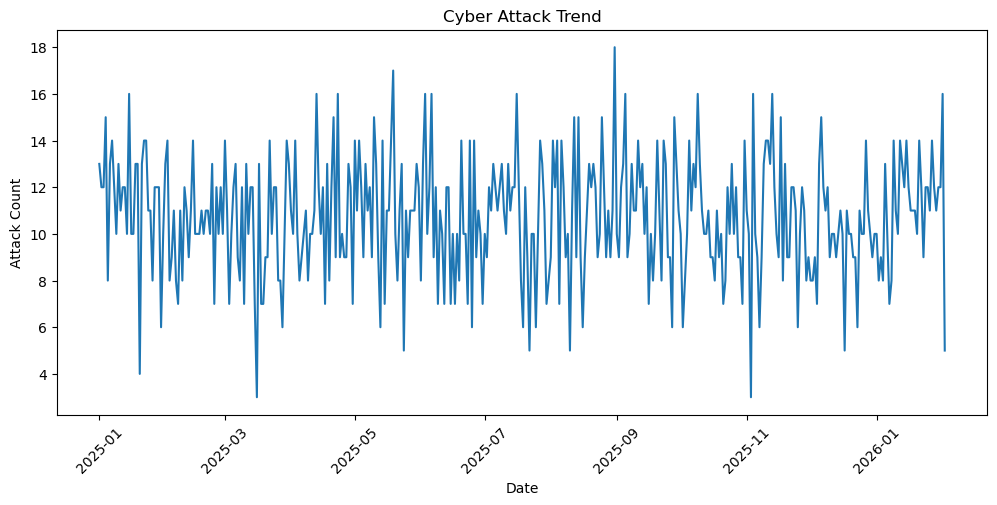

In [4]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_attacks['date'],
    daily_attacks['attack_count']
)

plt.title("Cyber Attack Trend")
plt.xlabel("Date")
plt.ylabel("Attack Count")

plt.xticks(rotation=45)

plt.show()

In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import joblib

daily_attacks = pd.read_csv( r"C:\Users\Admin\Desktop\PROJECT FILE\cybersecurity_intrusion_data.csv")

daily_attacks['day_number'] = np.arange(len(daily_attacks))

X = daily_attacks[['day_number']]
y = daily_attacks['attack_detected']

model = LinearRegression()
model.fit(X, y)

print("Trend Model Trained Successfully")

future_days = 30

future_x = np.arange(
    len(daily_attacks),
    len(daily_attacks) + future_days
).reshape(-1, 1)

future_predictions = model.predict(future_x)

future_df = pd.DataFrame({
    "Future_Day": range(1, future_days + 1),
    "Predicted_Attacks": future_predictions
})

joblib.dump(future_df, "future_attack_predictions.pkl")

print("Forecast saved successfully")

future_df.head()

Trend Model Trained Successfully
Forecast saved successfully


C:\Users\Admin\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Future_Day,Predicted_Attacks
0,1,0.444971
1,2,0.444970
2,3,0.444970
3,4,0.444969
4,5,0.444969


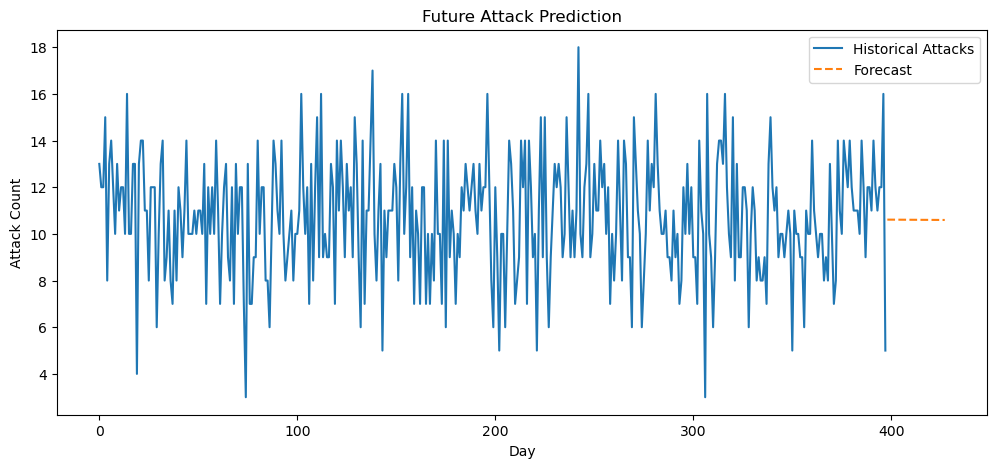

In [6]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_attacks['day_number'],
    daily_attacks['attack_detected'],
    label='Historical Attacks'
)

plt.plot(
    future_x,
    future_predictions,
    label='Forecast',
    linestyle='--'
)

plt.title("Future Attack Prediction")

plt.xlabel("Day")

plt.ylabel("Attack Count")

plt.legend()

plt.show()

In [7]:
average_future_attack = np.mean(future_predictions)

print("Average Predicted Attacks:", round(average_future_attack,2))

if average_future_attack < 5:
    risk_level = "LOW"

elif average_future_attack < 20:
    risk_level = "MEDIUM"

else:
    risk_level = "HIGH"

print("Forecast Risk Level:", risk_level)

Average Predicted Attacks: 10.6
Forecast Risk Level: MEDIUM


Potential Emerging Threat Days:
           date  attack_count  day_number
14   2025-01-15            16          14
102  2025-04-13            16         102
112  2025-04-23            16         112
138  2025-05-19            17         138
153  2025-06-03            16         153
156  2025-06-06            16         156
196  2025-07-16            16         196
242  2025-08-31            18         242
247  2025-09-05            16         247
281  2025-10-09            16         281
307  2025-11-04            16         307
316  2025-11-13            16         316
396  2026-02-01            16         396


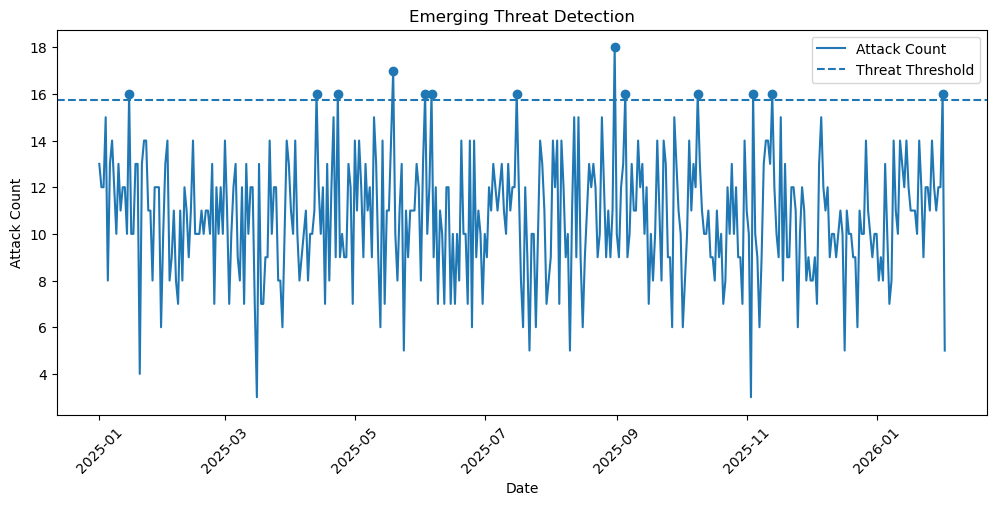

In [8]:
mean_attack = daily_attacks['attack_count'].mean()
std_attack = daily_attacks['attack_count'].std()

threshold = mean_attack + (2 * std_attack)

emerging_threats = daily_attacks[
    daily_attacks['attack_count'] > threshold
]

print("Potential Emerging Threat Days:")
print(emerging_threats)

plt.figure(figsize=(12,5))

plt.plot(
    daily_attacks['date'],
    daily_attacks['attack_count'],
    label='Attack Count'
)

plt.scatter(
    emerging_threats['date'],
    emerging_threats['attack_count']
)

plt.axhline(
    threshold,
    linestyle='--',
    label='Threat Threshold'
)

plt.title("Emerging Threat Detection")

plt.xlabel("Date")

plt.ylabel("Attack Count")

plt.legend()

plt.xticks(rotation=45)

plt.show()